# Notebook 4 — Simulation / Maintenance (ARI)

## Simulation de la stabilité du clustering dans le temps (ARI)

Objectif :
- évaluer la stabilité de la segmentation client dans le temps ;
- définir une fréquence de recalcul (contrat de maintenance).

Méthode :
- découpage temporel en périodes fixes ;
- reconstruction du fichier client RFM pour chaque période ;
- application du même modèle de clustering ;
- calcul de l’Adjusted Rand Index (ARI) entre périodes successives.


Simulation maintenance conforme à la méthode décrite : 10 points hebdomadaires, ARI(M0.predict vs Mi.fit) et seuil 0.8.


In [1]:
        import pandas as pd
        import numpy as np
        import matplotlib.pyplot as plt

        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans
        from sklearn.metrics import adjusted_rand_score

        base_path = r"C:\Users\mmaslouhi\Documents\Mission - Segmentez des clients d'un site e-commerce\archive"

        orders = pd.read_csv(base_path + r"\olist_orders_dataset.csv")
        order_items = pd.read_csv(base_path + r"\olist_order_items_dataset.csv")
        customers = pd.read_csv(base_path + r"\olist_customers_dataset.csv")

        orders = orders[orders["order_status"] == "delivered"].copy()

        order_items["item_total"] = order_items["price"] + order_items["freight_value"]
        order_amount = (
            order_items.groupby("order_id", as_index=False)["item_total"]
            .sum()
            .rename(columns={"item_total":"order_amount"})
        )
        orders = orders.merge(order_amount, on="order_id", how="left")

        orders["order_purchase_timestamp"] = pd.to_datetime(
            orders["order_purchase_timestamp"], errors="coerce"
        )

        orders_clients = orders.merge(
            customers[["customer_id","customer_unique_id"]],
            on="customer_id",
            how="left"
        ).dropna(subset=["order_purchase_timestamp"])

        orders_clients.shape


(96478, 10)

### Fonction Fi (min -> Ti)

In [2]:
def build_client_file_upto(df_orders_clients: pd.DataFrame, Ti: pd.Timestamp) -> pd.DataFrame:
    df = df_orders_clients[df_orders_clients["order_purchase_timestamp"] <= Ti].copy()
    reference_date = Ti + pd.Timedelta(days=1)

    rfm = (
        df.groupby("customer_unique_id")
        .agg(
            recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
            frequency=("order_id", "nunique"),
            monetary=("order_amount", "sum")
        )
        .reset_index()
    )
    return rfm


### Paramètres + entraînement M0 + 10 dates Ti

In [3]:
K_FINAL = 5
FEATURES = ["recency","frequency","monetary"]
STEP_DAYS = 7
N_POINTS = 10
THRESHOLD = 0.8

T_end = orders_clients["order_purchase_timestamp"].max().normalize()
T0 = (T_end - pd.Timedelta(days=STEP_DAYS * (N_POINTS + 2))).normalize()

F0 = build_client_file_upto(orders_clients, T0)
scaler0 = StandardScaler()
X0 = scaler0.fit_transform(F0[FEATURES])

M0 = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
_ = M0.fit_predict(X0)

Ti_list = [T0 + pd.Timedelta(days=STEP_DAYS*i) for i in range(1, N_POINTS+1)]
Ti_list[0], Ti_list[-1]


(Timestamp('2018-06-13 00:00:00'), Timestamp('2018-08-15 00:00:00'))

### Boucle ARI : M0.predict vs Mi.fit

In [4]:
results = []

for Ti in Ti_list:
    Fi = build_client_file_upto(orders_clients, Ti)

    Xi_init = scaler0.transform(Fi[FEATURES])
    C_init = M0.predict(Xi_init)

    scaler_i = StandardScaler()
    Xi_new = scaler_i.fit_transform(Fi[FEATURES])
    Mi = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
    C_new = Mi.fit_predict(Xi_new)

    ari = adjusted_rand_score(C_new, C_init)

    results.append({"Ti": Ti, "n_clients": len(Fi), "ari": ari})

ari_df = pd.DataFrame(results)
ari_df


,Ti,n_clients,ari
0,2018-06-13,77766,0.976827
1,2018-06-20,79146,0.956477
2,2018-06-27,80542,0.938113
3,2018-07-04,81817,0.892583
4,2018-07-11,82829,0.867982
5,2018-07-18,83940,0.763672
6,2018-07-25,85623,0.445108
7,2018-08-01,87214,0.448765
8,2018-08-08,89271,0.438499
9,2018-08-15,91028,0.430296


### Courbe ARI + délai de maintenance

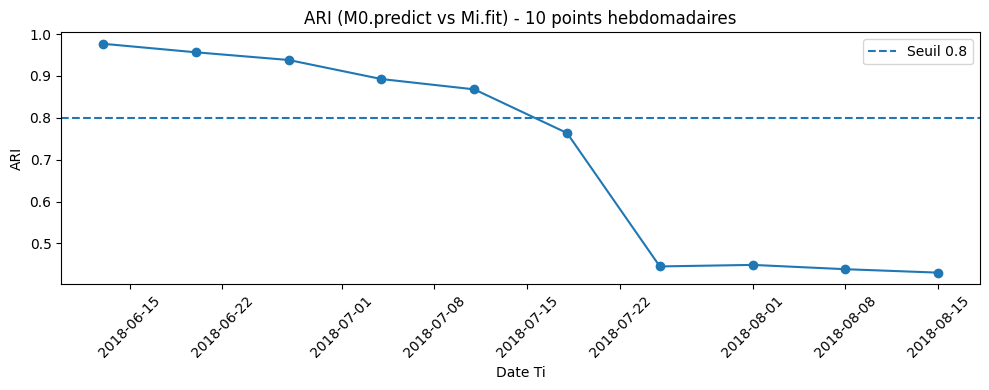

,Ti,n_clients,ari
count,10,10.000000,10.000000
mean,2018-07-14 12:00:00,83917.600000,0.715832
min,2018-06-13 00:00:00,77766.000000,0.430296
25%,2018-06-28 18:00:00,80860.750000,0.446022
50%,2018-07-14 12:00:00,83384.500000,0.815827
75%,2018-07-30 06:00:00,86816.250000,0.926730
max,2018-08-15 00:00:00,91028.000000,0.976827
std,NaN,4353.726608,0.243853


In [5]:
plt.figure(figsize=(10,4))
plt.plot(ari_df["Ti"], ari_df["ari"], marker="o")
plt.axhline(THRESHOLD, linestyle="--", label=f"Seuil {THRESHOLD}")
plt.xticks(rotation=45)
plt.title("ARI (M0.predict vs Mi.fit) - 10 points hebdomadaires")
plt.xlabel("Date Ti")
plt.ylabel("ARI")
plt.legend()
plt.tight_layout()
plt.show()

ari_df.describe()


In [6]:
below = ari_df[ari_df["ari"] < THRESHOLD]
if len(below) > 0:
    first_below = below.iloc[0]
    weeks_to_retrain = int(((first_below["Ti"] - T0).days) / 7)
    print("Première chute sous seuil :", first_below["Ti"].date())
    print("ARI =", round(first_below["ari"], 3))
    print("=> Recommandation : réentraîner toutes les", weeks_to_retrain, "semaines")
else:
    print("ARI reste >= seuil sur l'horizon testé.")


Première chute sous seuil : 2018-07-18
ARI = 0.764
=> Recommandation : réentraîner toutes les 6 semaines
